# Step 49 — Model C (Online/Passive-Aggressive Learning) on POWERGRID

Fresh rebuild of the video's Model C (MemLabs "How to handle Regime Changes"), on our own
DS3 data (POWERGRID) instead of BTC, using features actually validated in notebook 35's
Pearson r screening — not the reference code's default (weak) benchmark feature.

**What makes this "Model C" vs A/B**: not the feature count, but the *training mechanism*.
Model A/B fit once on a Train block (batch OLS). Model C uses **online/incremental learning**
(scikit-learn `SGDRegressor` configured for Passive-Aggressive updates) — it walks through the
data one row at a time, **predicts first** (using only weights learned from all *prior* rows),
**then** updates its weights with that row's true outcome. This makes every single prediction
(after a short warm-up) genuinely out-of-sample by construction — no separate Train/Test split
needed the way batch models require one.

**Epsilon** (0.0002 here, matching the reference code) is the "passive" tolerance band: if a
prediction is already within ±0.0002 of the true value, the model doesn't bother updating
(stays passive). Only when the miss exceeds epsilon does it aggressively correct its weights.

Plan: run Model C twice on POWERGRID — once with the reference code's original single feature
(`close_log_return_lag_1`, our "benchmark"), once with `rsi_lag_1` (our best-validated single
candidate from notebook 35, passed both the significance bar and the 10-year rolling-stability
check) — and compare hit rate + cumulative trade return directly.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler

plt.style.use('dark_background')


def compute_rsi(close, period=14):
    """Standard Wilder-smoothed RSI — same implementation as notebook 35."""
    delta = close.diff()
    gain = delta.where(delta > 0, 0.0)
    loss = -delta.where(delta < 0, 0.0)
    avg_gain = gain.ewm(alpha=1/period, min_periods=period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/period, min_periods=period, adjust=False).mean()
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

## Load POWERGRID daily data + build both candidate features

In [2]:
bars = pd.read_parquet('../../../../data/historical/intraday_5min_DS3/POWERGRID.parquet', columns=['datetime', 'close'])
bars['datetime'] = pd.to_datetime(bars['datetime'])
if bars['datetime'].dt.tz is not None:
    bars['datetime'] = bars['datetime'].apply(lambda x: x.replace(tzinfo=None))
bars['close'] = pd.to_numeric(bars['close'], errors='coerce')
bars.loc[bars['close'] <= 0, 'close'] = np.nan

pg = bars.set_index('datetime')['close'].resample('D').last().dropna().to_frame()
pg.rename(columns={'close': 'c'}, inplace=True)

pg['close_log_return'] = np.log(pg['c'] / pg['c'].shift())
pg['close_log_return_lag_1'] = pg['close_log_return'].shift()          # reference code's original feature
pg['rsi'] = compute_rsi(pg['c'])
pg['rsi_lag_1'] = pg['rsi'].shift()                                    # our best-validated candidate

print('POWERGRID daily rows:', len(pg))
pg.tail()

POWERGRID daily rows: 2810


,c,close_log_return,close_log_return_lag_1,rsi,rsi_lag_1
datetime,,,,,
2026-07-27,287.95,-0.003640,-0.001729,51.474311,53.367330
2026-07-28,285.30,-0.009246,-0.003640,46.948062,51.474311
2026-07-29,283.40,-0.006682,-0.009246,43.963165,46.948062
2026-07-30,285.90,0.008783,-0.006682,48.594364,43.963165
2026-07-31,284.00,-0.006668,0.008783,45.515587,48.594364


## Online learning loop (Passive-Aggressive, via SGDRegressor)

Same mechanism as the reference code: `partial_fit` a `StandardScaler` incrementally, predict
with the *pre-update* model, score directional hit/miss, then update the model with the true
outcome. Wrapped as a function so we can run it on any single feature.

In [3]:
def run_model_c(df, feature, target='close_log_return', epsilon=0.0002, seed=69):
    """Streaming Passive-Aggressive online learner, single feature. Returns df_results."""
    df_clean = df.dropna(subset=[feature, target])
    X_stream = df_clean[[feature]].to_numpy()
    y_stream = df_clean[target].to_numpy()
    dates = df_clean.index

    model = SGDRegressor(
        loss="epsilon_insensitive",
        epsilon=epsilon,
        penalty=None,
        learning_rate="pa1",
        eta0=0.01,
        random_state=seed,
    )
    scaler = StandardScaler()

    records = []
    for t in range(len(X_stream)):
        X_t = X_stream[t].reshape(1, -1)
        y_t = np.array([y_stream[t]])

        scaler.partial_fit(X_t)
        X_t_scaled = scaler.transform(X_t)

        # TEST STEP — predict BEFORE updating weights (out-of-sample by construction)
        if t == 0:
            pred_y = 0.0  # cold start
        else:
            pred_y = model.predict(X_t_scaled)[0]

        if t > 0 and y_t[0] != 0 and pred_y != 0:
            sign_match = "YES" if np.sign(y_t[0]) == np.sign(pred_y) else "NO"
        else:
            sign_match = "Warmup"

        # TRAIN STEP — update weights with the now-known true outcome
        model.partial_fit(X_t_scaled, y_t)

        signal = np.sign(pred_y)
        trade_log_return = signal * y_t[0]

        if sign_match != "Warmup":
            records.append({
                'date': dates[t],
                'x': X_t[0][0],
                'true_y': y_t[0],
                'pred_y_hat': pred_y,
                'sign_match': sign_match,
                'model_weight': model.coef_[0],
                'model_bias': model.intercept_[0],
                'signal': signal,
                'trade_log_return': trade_log_return,
            })

    df_results = pd.DataFrame(records).set_index('date')
    df_results['cum_trade_log_return'] = df_results['trade_log_return'].cumsum()

    evaluated = df_results['sign_match'].isin(['YES', 'NO'])
    hit_rate = (df_results.loc[evaluated, 'sign_match'] == 'YES').mean() * 100 if evaluated.sum() > 0 else np.nan

    return df_results, hit_rate

## Run 1 — benchmark feature (`close_log_return_lag_1`), matching the reference code exactly

In [4]:
results_benchmark, hit_rate_benchmark = run_model_c(pg, 'close_log_return_lag_1')
print(f'Model C (benchmark feature) — n={len(results_benchmark)}, hit rate={hit_rate_benchmark:.2f}%')
print('final cumulative trade log return:', round(results_benchmark["cum_trade_log_return"].iloc[-1], 4))
results_benchmark['signal'].value_counts()

Model C (benchmark feature) — n=2759, hit rate=48.21%
final cumulative trade log return: -0.7265


signal
 1.0    1383
-1.0    1376
Name: count, dtype: int64

## Run 2 — RSI(14) feature, our best-validated candidate from notebook 35

In [5]:
results_rsi, hit_rate_rsi = run_model_c(pg, 'rsi_lag_1')
print(f'Model C (RSI feature) — n={len(results_rsi)}, hit rate={hit_rate_rsi:.2f}%')
print('final cumulative trade log return:', round(results_rsi["cum_trade_log_return"].iloc[-1], 4))
results_rsi['signal'].value_counts()

Model C (RSI feature) — n=2747, hit rate=49.14%
final cumulative trade log return: -0.6893


signal
-1.0    1389
 1.0    1358
Name: count, dtype: int64

## Comparison

In [6]:
comparison = pd.DataFrame([
    {'feature': 'close_log_return_lag_1 (benchmark)', 'n': len(results_benchmark), 'hit_rate_%': round(hit_rate_benchmark, 2),
     'final_cum_trade_log_return': round(results_benchmark['cum_trade_log_return'].iloc[-1], 4)},
    {'feature': 'rsi_lag_1', 'n': len(results_rsi), 'hit_rate_%': round(hit_rate_rsi, 2),
     'final_cum_trade_log_return': round(results_rsi['cum_trade_log_return'].iloc[-1], 4)},
])
comparison

,feature,n,hit_rate_%,final_cum_trade_log_return
0,close_log_return_lag_1 (benchmark),2759,48.21,-0.7265
1,rsi_lag_1,2747,49.14,-0.6893


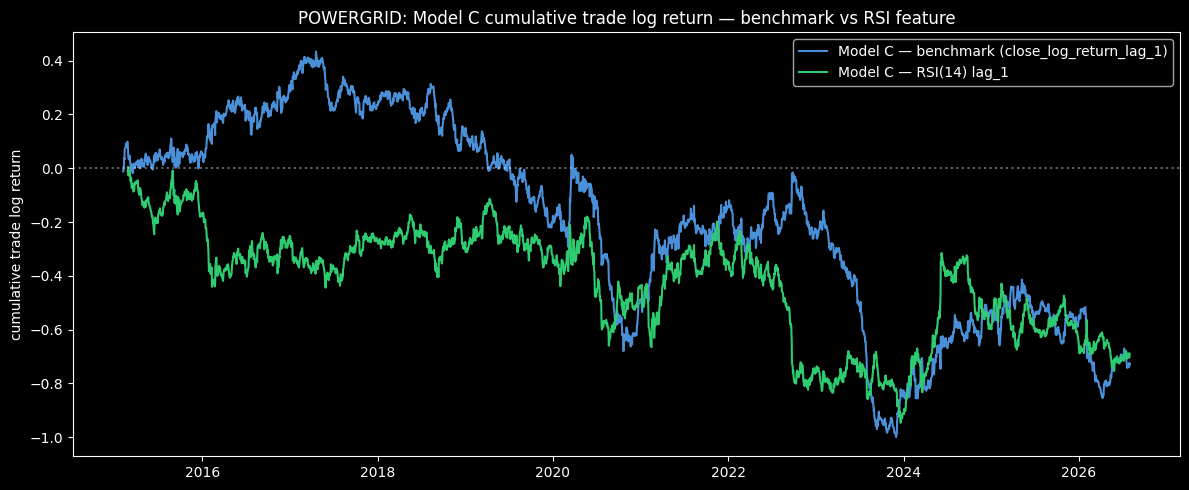

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(results_benchmark.index, results_benchmark['cum_trade_log_return'], color='#4a90d9', label='Model C — benchmark (close_log_return_lag_1)')
ax.plot(results_rsi.index, results_rsi['cum_trade_log_return'], color='#2ecc71', label='Model C — RSI(14) lag_1')
ax.axhline(0, color='white', linestyle=':', alpha=0.4)
ax.set_title('POWERGRID: Model C cumulative trade log return — benchmark vs RSI feature')
ax.set_ylabel('cumulative trade log return')
ax.legend()
plt.tight_layout()
plt.show()